# Electric cars in the passenger car stock

Dual-axis line plot from `Elektroautos_im_PKW_Bestand.csv` (`;`-separated): BEV stock in
millions on the left axis, its share of the passenger-car stock on the right axis, 2015-2025.

Both series grow from 0.02 million / 0.04 % in 2015 to 1.65 million / 3.35 % in 2025, so on
their own scales the two curves nearly coincide.

The figure is written to `<date>_<time>_out_<i>.pdf` next to this notebook.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [ ]:
from datetime import datetime
from pathlib import Path

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
OUT_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(file_format: str) -> Path:
    """Next '<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    return OUT_DIR / f"{OUT_RUN_STAMP}_out_{out_index}.{file_format}"


In [2]:
df = pd.read_csv("Elektroautos_im_PKW_Bestand.csv", sep=";")
df.columns = ["year", "cars_millions", "share_pct"]
df

,year,cars_millions,share_pct
0,2015,0.02,0.04
1,2016,0.03,0.06
2,2017,0.03,0.07
3,2018,0.05,0.12
4,2019,0.08,0.18
5,2020,0.14,0.29
6,2021,0.31,0.64
7,2022,0.62,1.27
8,2023,1.01,2.08
9,2024,1.41,2.87


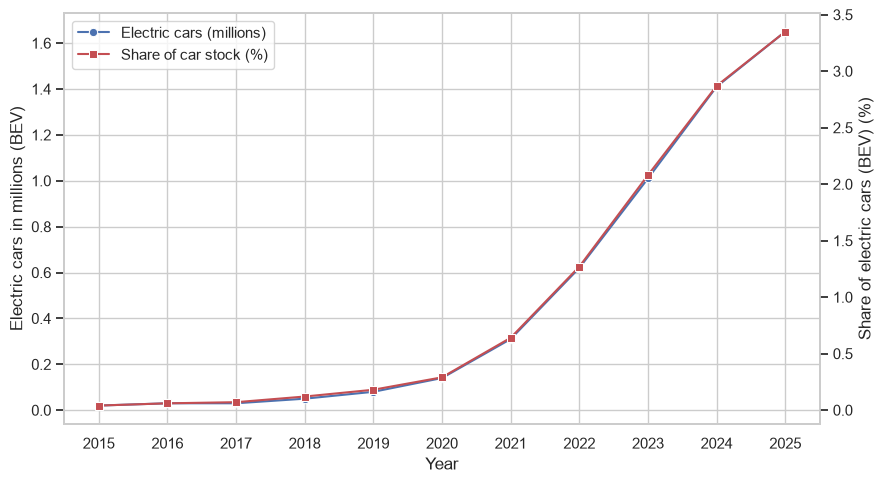

In [3]:
fig, ax1 = plt.subplots(figsize=(9, 5))

color1 = sns.color_palette("deep")[0]
color2 = sns.color_palette("deep")[3]

# Left y-axis: electric cars in millions
sns.lineplot(data=df, x="year", y="cars_millions", marker="o",
             color=color1, ax=ax1, label="Electric cars (millions)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Electric cars in millions (BEV)")

# Right y-axis: share of car stock
ax2 = ax1.twinx()
ax2.grid(False)
sns.lineplot(data=df, x="year", y="share_pct", marker="s",
             color=color2, ax=ax2, label="Share of car stock (%)")
ax2.set_ylabel("Share of electric cars (BEV) (%)")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
if ax1.get_legend() is not None:
    ax1.get_legend().remove()
if ax2.get_legend() is not None:
    ax2.get_legend().remove()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_xticks(df["year"])
fig.tight_layout()

out_path = next_out_path("pdf")
fig.savefig(out_path, bbox_inches="tight")
print(f"saved {out_path}")
plt.show()